## **Notebook 4: `High-Demand Forecasting`**


## **1. Importing the necessary libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

## **2. Loading monthly trends**

In [2]:
monthly_category = pd.read_csv(r"D:\Project 8\monthly_trends.csv")
monthly_category.head()

,year_month,category,job_count
0,2023-11,Other,1
1,2023-12,AI_ML_Data,2
2,2023-12,Design_Creative,1
3,2023-12,Marketing_SEO,2
4,2023-12,Other,5


## **3. Selecting one category for forecasting**

**Time Series of job counts over time**

In [3]:
category_name = "AI_ML_Data"

series_df = monthly_category[monthly_category["category"] == category_name].copy()
series_df["year_month"] = pd.to_datetime(series_df["year_month"])
series_df = series_df.sort_values("year_month")
series_df.set_index("year_month", inplace=True)

ts = series_df["job_count"]
ts

year_month
2023-12-01        2
2024-01-01        7
2024-02-01     9969
2024-03-01    13997
Name: job_count, dtype: int64

## **4. Train-test split**

In [4]:
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

## **5. Fitting ARIMA model**

In [5]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test))

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


## **6. Evaluation**

In [6]:
# calculate metrics
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

# print results
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 12537.102006679499
RMSE: 12537.102006679499


## **7. Forecast Plot actual vs predicted**

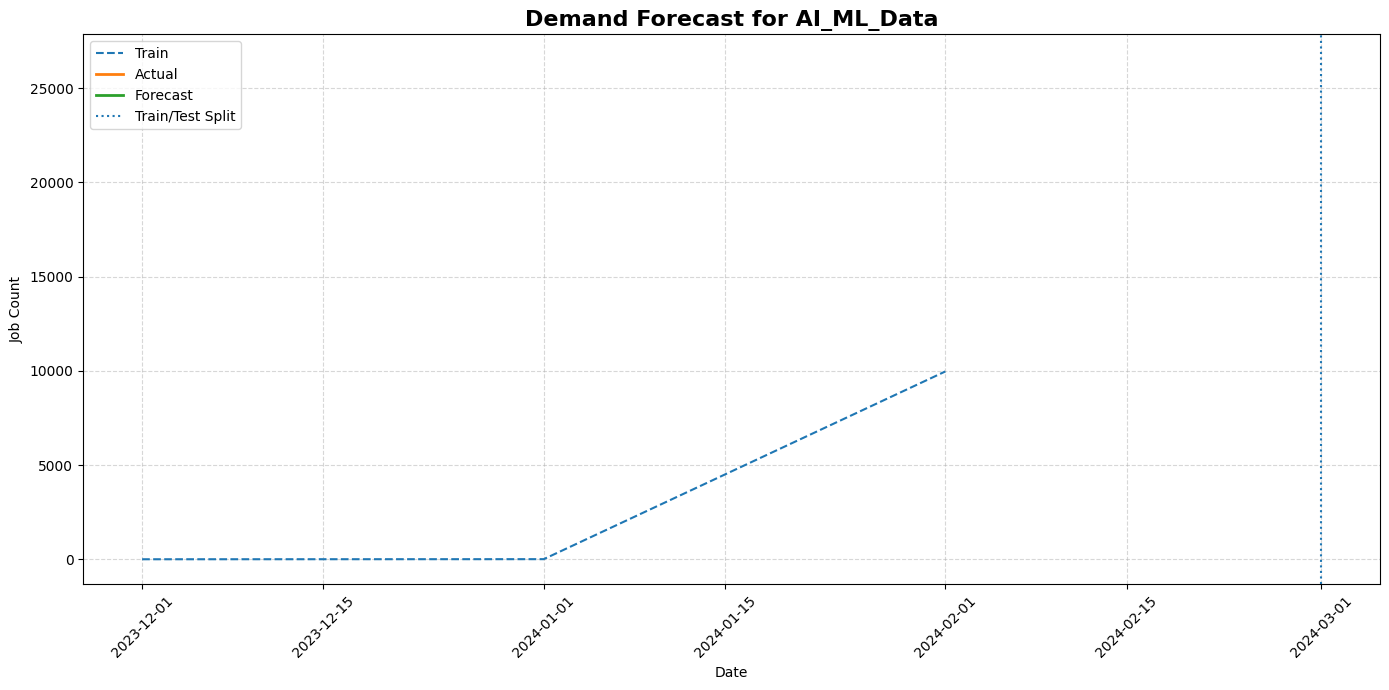

In [7]:
plt.figure(figsize=(14, 7))

plt.plot(train.index, train, label="Train", linestyle="--")
plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, forecast, label="Forecast", linewidth=2)

# Add vertical split line
plt.axvline(x=test.index[0], linestyle=":", label="Train/Test Split")

plt.title(f"Demand Forecast for {category_name}", fontsize=16, weight='bold')
plt.xlabel("Date")
plt.ylabel("Job Count")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **8. Future forecasting**

In [8]:
future_steps = 3
future_forecast = model_fit.forecast(steps=future_steps)
future_forecast

2024-03-01    26534.102007
2024-04-01    43099.114951
2024-05-01    59664.038832
Freq: MS, Name: predicted_mean, dtype: float64

## **9. Forecasting for top categories in loop**

In [9]:
categories = monthly_category["category"].unique()
forecast_results = []

for cat in categories:
    temp = monthly_category[monthly_category["category"] == cat].copy()
    temp["year_month"] = pd.to_datetime(temp["year_month"])
    temp = temp.sort_values("year_month").set_index("year_month")
    ts = temp["job_count"]

    if len(ts) >= 4:
        try:
            model = ARIMA(ts, order=(1,1,1))
            fitted = model.fit()
            next_val = fitted.forecast(steps=1).iloc[0]

            forecast_results.append({
                "category": cat,
                "predicted_next_period_jobs": next_val
            })
        except:
            pass

forecast_df = pd.DataFrame(forecast_results).sort_values("predicted_next_period_jobs", ascending=False)
forecast_df

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  

,category,predicted_next_period_jobs
0,Other,92091.510309
2,Design_Creative,21464.625039
3,Marketing_SEO,12704.594882
1,AI_ML_Data,12396.712226


## **10. Saving model outputs**

In [10]:
forecast_df.to_csv("category_forecast_summary.csv", index=False)